# Module 3 — Lab C: Model Training with MLflow Experiment Tracking
## Train Classification Models, Compare Metrics & Register the Best Model

---

### Lab Overview

With the feature matrix produced in **Lab B** (`final_features.csv`, ~12,308 rows x 37 columns), you will now **train three classification models**, evaluate them on multiple metrics, and **track every experiment in MLflow** running on your EC2 instance.

FreshBasket's logistics team (Priya is the ML lead, Arjun handles DevOps) needs a model that predicts whether a truck delivery will be **delayed** (target = 1) or **on-time** (target = 0). A single accuracy number is not enough — the operations team cares about **recall** (catching delayed shipments) while finance cares about **precision** (avoiding false alarms that trigger costly rerouting at ₹8,000 per unnecessary intervention).

| Step | What We Do | Key Technology |
|------|-----------|----------------|
| 1 | Environment setup + MLflow connection | `mlflow`, `boto3` |
| 2 | Load `final_features.csv` from S3 or local | `pandas`, `boto3` |
| 3 | Train / Validation / Test split (70/15/15) | `train_test_split` (stratified) |
| 4 | Preprocess: OneHotEncode + StandardScale | `OneHotEncoder`, `StandardScaler` |
| 5 | Train Logistic Regression (baseline) | `LogisticRegression` + MLflow |
| 6 | Train Random Forest | `RandomForestClassifier` + MLflow |
| 7 | Train XGBoost | `XGBClassifier` + MLflow |
| 8 | Compare all models side-by-side | Comparison DataFrame + bar chart |
| 9 | Final evaluation on held-out test set | Best model on unseen data |
| 10 | Register best model in MLflow Model Registry | `mlflow.register_model()` |
| 11 | Save artifacts to S3 | `boto3` upload |

### Learning Objectives

By the end of this lab you will be able to:

1. Connect a Jupyter notebook to a **self-hosted MLflow Tracking Server** on EC2.
2. Train and evaluate **Logistic Regression**, **Random Forest**, and **XGBoost** classifiers.
3. Log **parameters, metrics, artifacts, and models** to MLflow for every experiment run.
4. Interpret classification metrics — **Accuracy, Precision, Recall, F1 Score, ROC-AUC** — and explain what each means for the business.
5. **Register** the best-performing model in the MLflow Model Registry and transition it to **Staging**.
6. Upload trained model artifacts (model, encoder, scaler) to **S3** for downstream use in Lab D.

### Artifact Chain

```
Lab B  --------------------------->  Lab C  --------------------------->  Lab D
saves: final_features.csv (S3)      saves: xgboost_model.pkl           loads: model + encoder + scaler
                                           encoder.pkl                  Streamlit dashboard
                                           scaler.pkl                   Batch scoring pipeline
                                           model_metadata.json
                                    logs:  3 MLflow experiment runs
```

---


### How to read this notebook

- **Markdown cells (like this one)** explain *why* the next cell exists and what to look for in its output.
- **Code cells** do the work. They're idempotent — re-run any of them safely.
- **"What this tells us" callouts** follow major result-producing cells. Don't just read the metrics — read the interpretation.
- The lab is **executable end-to-end on a SageMaker notebook** without writing back to the instructor's S3. The only output that needs S3 write access is Section 13, which is wrapped in `try/except` and will gracefully skip if you don't have credentials.
- If you change a hyperparameter and re-run a model cell, you'll get a **new MLflow run** automatically — that's the point. Compare them in the MLflow UI.

---


## 1. Environment Setup

> **SageMaker Notebook:** Run the cell below as-is — most packages are pre-installed.
>
> **Local Jupyter:** Uncomment the `pip install` line and run once.
>
> **Google Colab:** Uncomment the `pip install` line and run once.

**The imports cell.** Six libraries do most of the work:

- `pandas` + `numpy` — data + arrays
- `matplotlib` + `seaborn` — plots (we generate ~10 figures across 3 models)
- `scikit-learn` — `train_test_split`, `OneHotEncoder`, `StandardScaler`, `LogisticRegression`, `RandomForestClassifier`, all the metrics
- `xgboost` — gradient-boosted trees (the third model)
- `mlflow` — experiment tracking + the model registry
- `boto3` + `joblib` — only used at the very end for S3 upload and local model pickling

`warnings.filterwarnings('ignore')` silences some chatty deprecation warnings from sklearn / xgboost. Don't do this in production code — fine for a teaching notebook.


In [1]:
# -- Uncomment the line below if running locally or on Colab --
# !pip install pandas numpy matplotlib seaborn scikit-learn xgboost mlflow boto3 joblib -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, RocCurveDisplay)
import xgboost as xgb
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import joblib
import boto3
import json
import os
import warnings
warnings.filterwarnings('ignore')

# -- Display settings --
pd.set_option('display.max_columns', 40)
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

print("All libraries imported successfully")

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/pydantic/_internal/_fields.py:132: UserWarning: Field "model_name" in PromptModelConfig has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(
/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All libraries imported successfully


**MLflow configuration + connectivity smoke-test.** Three constants and a defensive connection block:

1. **`MLFLOW_TRACKING_URI`** — where your MLflow tracking server lives. Two patterns:
   - Local on this notebook: `"sqlite:///mlflow.db"` (recommended — see the M3 README)
   - Shared MLflow on the instructor's EC2: `"http://<EC2_IP>:5000"`
2. **`EXPERIMENT_NAME`** — runs from this notebook are grouped under this name in the MLflow UI.
3. **`S3_BUCKET` / `S3_DATA_KEY` / `S3_MODEL_DIR`** — only matter if you have AWS credentials configured.

The `try / except` block tries to reach MLflow; if it can't (offline, wrong IP, bucket of cookies blocking us), it transparently falls back to `mlruns/` on the notebook's local disk. Every `mlflow.log_param` / `log_metric` call still works — they just write to local files instead of the server.

> **Production-y tip.** Hardcoding the EC2 IP works for class but is brittle (the IP changes every redeploy). In real life you'd put it in an env var or read it from CloudFormation outputs at startup.


In [2]:
# ================================================================
#  MLflow Configuration
# ================================================================
# Replace <EC2_PUBLIC_IP> with your EC2 instance's public IP address.
# Example: "http://54.210.85.123:5000"
# If running MLflow locally: "http://127.0.0.1:5000"

MLFLOW_TRACKING_URI = "http://52.66.194.203:5000"   # <-- EDIT THIS
EXPERIMENT_NAME     = "truck-delay-classification"

# -- S3 Configuration --
S3_BUCKET = 'mlops-m3-batch-2026-658174223290'   # Replace with your bucket name
S3_DATA_KEY  = "data/final_features.csv"
S3_MODEL_DIR = "models/truck-delay/"

# -- Try connecting to MLflow; fall back to local if unreachable --
try:
    mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
    mlflow.set_experiment(EXPERIMENT_NAME)
    # Quick connectivity test
    mlflow.search_experiments()
    print(f"Connected to MLflow server: {MLFLOW_TRACKING_URI}")
    print(f"Experiment: '{EXPERIMENT_NAME}'")
    MLFLOW_AVAILABLE = True
except Exception as e:
    print(f"Could not reach MLflow at {MLFLOW_TRACKING_URI}")
    print(f"Error: {e}")
    print("Falling back to local MLflow tracking (./mlruns)")
    mlflow.set_tracking_uri("mlruns")
    mlflow.set_experiment(EXPERIMENT_NAME)
    MLFLOW_AVAILABLE = False

print(f"\nMLflow tracking URI: {mlflow.get_tracking_uri()}")

Connected to MLflow server: http://52.66.194.203:5000
Experiment: 'truck-delay-classification'

MLflow tracking URI: http://52.66.194.203:5000


## 2. Load Feature Matrix

The feature matrix was created in **Lab C** and saved to S3 as `final_features.csv`. It contains **~12,308 rows** (one per scheduled truck trip) and **37 columns** (36 features + 1 target called `delay`).

We try to load from S3 first. If that fails (e.g., you are offline or the bucket is not set up yet), we fall back to a local copy.

**Load `final_features.csv` — S3 first, local fallback.** This is the artifact Lab B produced. Three things happen:

1. Try `s3.download_file(...)` — pulls the CSV from your team's S3 bucket. If your AWS creds are set and the bucket has the file, this just works.
2. If S3 fails, look for a local copy at `data/processed/final_features.csv`.
3. If neither exists, raise `FileNotFoundError` with a clear hint to run Lab B first.

The `df.shape` print should show roughly **(12,308, 37)** — 36 features + the `delay` target. The `dtypes.value_counts()` tells you how many numeric vs. object columns you have, useful for catching unexpected stringification.


In [3]:
# -- Load final_features.csv from S3 or local fallback --
LOCAL_PATH = "data/processed/final_features.csv"

try:
    s3 = boto3.client('s3')
    s3.download_file(S3_BUCKET, S3_DATA_KEY, LOCAL_PATH)
    print(f"Downloaded from S3: s3://{S3_BUCKET}/{S3_DATA_KEY}")
except Exception as e:
    print(f"S3 download failed: {e}")
    print(f"Looking for local file: {LOCAL_PATH}")
    if not os.path.exists(LOCAL_PATH):
        raise FileNotFoundError(
            f"{LOCAL_PATH} not found locally either.\n"
            "Run Lab B first, or upload final_features.csv to this directory."
        )

df = pd.read_csv(LOCAL_PATH)
print(f"\nLoaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nColumn dtypes:\n{df.dtypes.value_counts()}")

S3 download failed: An error occurred (404) when calling the HeadObject operation: Not Found
Looking for local file: data/processed/final_features.csv

Loaded: 12,308 rows x 37 columns

Column dtypes:
float64    23
int64       8
object      6
Name: count, dtype: int64


**Five sanity checks before training.** These all run in the next few cells (target distribution, missing values, duplicates, feature count, head sample). Skipping these is how you end up training a model on a dataset where some sneaky column got corrupted in the previous step.

**What you want to see:**
- Target distribution roughly 60 / 40 (on-time / delayed) — matches Lab B's analysis
- Missing values: 0 (we filled them in Lab B's Section 10)
- Duplicate rows: 0 (each scheduled trip should be unique)
- Total columns: 37 = 36 features + 1 target


In [4]:
# -- Sanity checks --
print("=" * 55)
print("  DATA SANITY CHECKS")
print("=" * 55)

# Target distribution
print(f"\n1. Target variable -- 'delay':")
target_counts = df['delay'].value_counts()
print(f"   On-Time (0): {target_counts.get(0, 0):,}  ({target_counts.get(0, 0)/len(df)*100:.1f}%)")
print(f"   Delayed (1): {target_counts.get(1, 0):,}  ({target_counts.get(1, 0)/len(df)*100:.1f}%)")

  DATA SANITY CHECKS

1. Target variable -- 'delay':
   On-Time (0): 8,014  (65.1%)
   Delayed (1): 4,294  (34.9%)


In [5]:
# Missing values
n_missing = df.isnull().sum().sum()
print(f"\n2. Missing values: {n_missing}")


2. Missing values: 0


In [6]:
# Duplicates
n_dupes = df.duplicated().sum()
print(f"3. Duplicate rows: {n_dupes}")

3. Duplicate rows: 0


In [7]:
# Feature breakdown
print(f"\n4. Feature breakdown:")
print(f"   Total columns:  {df.shape[1]}")
print(f"   Features:       {df.shape[1] - 1}")
print(f"   Target:         1 (delay)")


4. Feature breakdown:
   Total columns:  37
   Features:       36
   Target:         1 (delay)


In [8]:

**Defining column groups for preprocessing.** Three lists that drive the rest of Section 4:

- **`CATEGORICAL_COLS`** (6 cols) — get one-hot encoded. `route_description`, `origin_description`, `dest_description` are *weather description* labels like "Heavy snow" / "Sunny" / "Foggy" — confusingly named, but they're categorical text fields, not route/city names. You'll see in the next cell that `route_description` alone has **46 unique values** (one per granular weather state observed along the route).
- **`BINARY_ORDINAL_COLS`** (3 cols) — `accident` (0/1), `ratings` (1-5), `is_midnight` (0/1). These are already in a numeric form the model can consume; we pass them through unchanged.
- **`CONTINUOUS_COLS`** — everything else. They get standard-scaled (mean 0, std 1) so features like `distance` (hundreds of miles) and `humidity` (0-100) end up on comparable scales.

> **Bug fix in this cell.** The original code looked for `destination_description` but Lab B saves the column as `dest_description`. The KeyError that produced cascaded through the rest of Section 4. Fixed in place — the rest of the section now runs end-to-end.



5. First 3 rows:


,route_avg_temp,route_avg_wind_speed,route_avg_precip,route_avg_humidity,route_avg_visibility,route_avg_pressure,origin_avg_temp,origin_avg_wind_speed,origin_avg_precip,origin_avg_humidity,origin_avg_visibility,origin_avg_pressure,dest_avg_temp,dest_avg_wind_speed,dest_avg_precip,dest_avg_humidity,dest_avg_visibility,dest_avg_pressure,truck_age,load_capacity_pounds,mileage_mpg,age,experience,average_speed_mph,avg_no_of_vehicles,distance,average_hours,route_description,origin_description,dest_description,accident,fuel_type,gender,driving_style,ratings,is_midnight,delay
0,31.00,4.25,0.0,86.00,6.0,1009.50,26.041667,10.5,0.0,80.625,5.25,1027.416667,39.000000,9.958333,0.0,82.208333,6.000000,1022.916667,9,3000.0,23,48,9,57.36,1717.250000,310.75,6.22,Clear,Light snow,Overcast,0,diesel,male,proactive,7,0,0
1,43.25,9.25,0.0,78.50,6.0,1021.25,26.041667,10.5,0.0,80.625,5.25,1027.416667,-2.416667,2.833333,0.0,82.583333,6.000000,1037.416667,7,15000.0,21,47,12,57.04,1725.583333,1050.84,21.02,Partly cloudy,Light snow,Sunny,1,diesel,male,proactive,8,1,0
2,24.00,7.00,0.0,63.75,5.5,1019.75,26.041667,10.5,0.0,80.625,5.25,1027.416667,28.541667,10.125000,0.0,82.250000,4.458333,1026.458333,10,3000.0,26,43,6,64.11,1717.250000,38.10,0.76,Clear,Light snow,Moderate snow,0,diesel,male,proactive,8,0,0


**Defining column groups for preprocessing.** Three lists that drive the rest of Section 4:

- **`CATEGORICAL_COLS`** (6 cols) — get one-hot encoded. `route_description`, `origin_description`, `dest_description` are *weather description* labels like "Heavy snow" / "Sunny" / "Foggy" — confusingly named, but they're categorical text fields, not route/city names.
- **`BINARY_ORDINAL_COLS`** (3 cols) — `accident` (0/1), `ratings` (1-5), `is_midnight` (0/1). These are already in a numeric form the model can consume; we pass them through unchanged.
- **`CONTINUOUS_COLS`** — everything else. They get standard-scaled (mean 0, std 1) so features like `distance` (hundreds of miles) and `humidity` (0-100) end up on comparable scales.

> **Bug fix in this cell.** The original code looked for `destination_description` but Lab B saves the column as `dest_description`. The KeyError that produced cascaded through the rest of Section 4. Fixed in place — the rest of the section now runs end-to-end.


In [9]:
# ================================================================
#  Identify column groups
# ================================================================
# Target
TARGET = 'delay'

# 6 categorical columns that need one-hot encoding
CATEGORICAL_COLS = [
    'route_description',       # e.g., "Pune-Mumbai", "Delhi-Jaipur"
    'origin_description',      # origin city name
    'dest_description',        # destination city name (Lab B saved this as dest_, not destination_)
    'fuel_type',               # Diesel, CNG, etc.
    'gender',                  # driver gender
    'driving_style',           # Cautious, Normal, Aggressive
]

# 3 columns that are already binary or ordinal -- no encoding needed
BINARY_ORDINAL_COLS = [
    'accident',     # 0 or 1
    'ratings',      # ordinal 1-5
    'is_midnight',  # 0 or 1
]

# Everything else (excluding target and categoricals) is continuous
ALL_NON_FEATURE = [TARGET] + CATEGORICAL_COLS + BINARY_ORDINAL_COLS
CONTINUOUS_COLS = [c for c in df.columns if c not in ALL_NON_FEATURE]

print(f"Categorical (to one-hot encode): {len(CATEGORICAL_COLS)}")
for c in CATEGORICAL_COLS:
    n_unique = df[c].nunique()
    print(f"  - {c}: {n_unique} unique values")

print(f"\nBinary / Ordinal (keep as-is):   {len(BINARY_ORDINAL_COLS)}")
print(f"Continuous (to scale):           {len(CONTINUOUS_COLS)}")
print(f"Target:                          1 ({TARGET})")
print(f"\nTotal:  {len(CATEGORICAL_COLS)} + {len(BINARY_ORDINAL_COLS)} + {len(CONTINUOUS_COLS)} + 1 = {df.shape[1]}")

Categorical (to one-hot encode): 6
  - route_description: 46 unique values
  - origin_description: 24 unique values
  - dest_description: 26 unique values
  - fuel_type: 3 unique values
  - gender: 3 unique values
  - driving_style: 3 unique values

Binary / Ordinal (keep as-is):   3
Continuous (to scale):           27
Target:                          1 (delay)

Total:  6 + 3 + 27 + 1 = 37


## 3. Train / Validation / Test Split

We use a **70 / 15 / 15** split with **stratification** on the `delay` target.

**Why stratified?** If 55% of trips are on-time and 45% are delayed, every split should preserve that ratio. Without stratification, one split might end up with 60% on-time by random chance, skewing the metrics.

**Why three splits, not two?**
- **Training set (70%)** — the model learns from this.
- **Validation set (15%)** — we tune and compare models on this. All three models are evaluated on the *same* validation set so comparisons are fair.
- **Test set (15%)** — touched only *once*, at the very end, to report the final unbiased performance of the winning model.

**The 70 / 15 / 15 split with stratification.** Done in two `train_test_split` calls because sklearn doesn't have a built-in 3-way split:

```
                 Original (12,308 rows)
                          |
              train_test_split(test_size=0.30)
                /                       \
       Train (70%)                Temp (30%)
                                          |
                              train_test_split(test_size=0.50)
                                /                       \
                       Validation (15%)            Test (15%)
```

**`stratify=y`** ensures the delay rate (~40%) is preserved in every split. Without it, a random split might give you a train set with 35% delayed and a test set with 47% — your metrics become noisy and incomparable.

**`random_state=42`** — for reproducibility. Same seed → same splits every run. Standard practice.


In [10]:

### What this tells us

- The **actual class balance is ~65/35** (on-time / delayed), not the 60/40 you might have remembered from Lab B. Stratification preserved this exactly across all three splits — train, validation, and test each show 34.9% delayed.
- 8,615 training rows is comfortably in the "enough data" zone for tabular classifiers. Validation and test sets at ~1,846 rows each give us metric estimates with a standard error around ±0.01 — meaningful for comparing models that differ by 0.02+ in F1.
- If the per-split delay rates differed by even a few percent, your split is broken — go back and check `stratify=y`.


  SPLIT SUMMARY
  Train       : 8,615 rows  |  Delayed: 34.9%
  Validation  : 1,846 rows  |  Delayed: 34.9%
  Test        : 1,847 rows  |  Delayed: 34.9%

  Total: 12,308 rows


### What this tells us

- Each split's delay rate should be within **±0.5%** of the overall ~40% rate. That's stratification working.
- Total row count must sum back to the original 12,308 — if not, you've lost data.
- The validation set has ~1,846 rows. That's enough that small metric differences between models are meaningful (we'll see deltas of 0.01-0.05 in F1, which is well above the noise floor for a sample this size).

If the test set delay rate is meaningfully different from the train/val delay rate, your split is broken — go back and verify `stratify=y`.



**One-hot encoding the 6 categorical columns.** `OneHotEncoder` learns a one-column-per-value mapping. Three important flags:

- **`drop='first'`** — drops the first category of each feature to avoid the dummy-variable trap (perfect multicollinearity). With route_description having 46 categories, this saves us 6 columns total (one per categorical feature).
- **`handle_unknown='ignore'`** — if Lab D sees a category at inference time that wasn't in training, the encoder outputs all-zeros for that row's encoding instead of crashing. Critical for production.
- **`sparse_output=False`** — return a regular numpy array, not a scipy sparse matrix. We have ~100 new columns, modest enough that the memory savings of sparse aren't worth the API hassle.

**`encoder.fit(X_train[...])` then `.transform(...)` on all 3 splits.** Fitting only on train is the canonical pattern to prevent data leakage — validation and test are transformed using the train-derived mapping.

> Expected output: 6 categorical → ~98 encoded columns. `route_description` accounts for most of the expansion (46 distinct weather states observed in the routes_weather data).


**One-hot encoding the 6 categorical columns.** `OneHotEncoder` learns a one-column-per-value mapping. Three important flags:

- **`drop='first'`** — drops the first category of each feature to avoid the dummy-variable trap (perfect multicollinearity). 6 columns with ~5 values each → ~24 new columns instead of ~30.
- **`handle_unknown='ignore'`** — if Lab D sees a category at inference time that wasn't in training, the encoder outputs all-zeros for that row's encoding instead of crashing. Critical for production.
- **`sparse_output=False`** — return a regular numpy array, not a scipy sparse matrix. We have only ~30 new columns, so the memory savings of sparse aren't worth the API hassle.

**`encoder.fit(X_train[...])` then `.transform(...)` on all 3 splits.** Fitting only on train is the canonical pattern to prevent data leakage — validation and test are transformed using the train-derived mapping.


In [11]:

### What this tells us

- **6 categorical columns expanded to 98 one-hot columns** — much more than you might have guessed. The breakdown:
  - `route_description`: **46 unique values** (one per fine-grained weather state along the route — "Heavy snow", "Light rain at times", "Patchy freezing fog", etc.)
  - `origin_description`: 24 unique values
  - `dest_description`: 26 unique values
  - `fuel_type`: 3 unique values
  - `gender`: 3 unique values
  - `driving_style`: 3 unique values
- The categorical "weather description" columns dominate the dimensionality. This is your first sign that **weather conditions carry significant categorical signal** beyond the numeric temperature / precip values we already have.
- `drop_first=True` shaved off ~6 columns (one per original feature). Without it we'd have ~105 instead of 98.
- The final feature matrix in cell 29 will be **128 columns** = 98 one-hot + 27 scaled-continuous + 3 binary-ordinal.


One-hot encoded columns: 6 original -> 98 encoded

Encoded feature names (first 15):
   1. route_description_Blowing snow
   2. route_description_Clear
   3. route_description_Cloudy
   4. route_description_Fog
   5. route_description_Freezing fog
   6. route_description_Heavy freezing drizzle
   7. route_description_Heavy rain
   8. route_description_Heavy rain at times
   9. route_description_Heavy snow
  10. route_description_Ice pellets
  11. route_description_Light drizzle
  12. route_description_Light freezing rain
  13. route_description_Light rain
  14. route_description_Light rain shower
  15. route_description_Light sleet
  ... and 83 more


### What this tells us

- 6 categorical columns expand to ~25-30 one-hot columns (depending on how many unique values each column has).
- `route_description` (the route's typical weather) usually expands the most — maybe 8-12 unique weather descriptions across all routes.
- `gender` produces only 1 new column after drop_first (Male encoded as 1, Female as 0).
- Total feature count after one-hot is now in the ~50-55 range. We'll add the continuous + binary back in cell 19 to get the final shape.


**Standard-scaling the continuous columns.** `StandardScaler` subtracts the mean and divides by the standard deviation, per column. Output: every continuous column has **mean ≈ 0, std ≈ 1** after scaling.

**Why scale?**
- **Logistic Regression** assumes features are on comparable scales — without scaling, the regularization term penalizes large-scaled features much more than small-scaled ones.
- **Random Forest and XGBoost** don't strictly need scaling (they split on percentile thresholds), but it doesn't hurt them.
- Consistent scaling means **all three models share the same preprocessing** — fairer comparison.

Same `fit on train / transform all three` pattern as one-hot encoding.


In [32]:

### What this tells us

- The `.describe()` block shows every continuous column with **mean = 0.0 and std = 1.0** on the training set (rounded to 1 decimal). Scaler fit cleanly.
- Validation and test sets will have mean / std slightly different from 0 / 1 (the scaler wasn't fit on them) — that's expected and correct.
- 27 continuous features × scaled = 27 columns of unit-variance numeric data. Logistic Regression will treat each of these as "one penalized coefficient" — without scaling, large-magnitude features like `load_capacity_pounds` (thousands) would absorb most of the L2 penalty and small features would be ignored.


Scaled 27 continuous features

Training set stats after scaling (should be ~mean=0, std=1):


,route_avg_temp,route_avg_wind_speed,route_avg_precip,route_avg_humidity,route_avg_visibility,route_avg_pressure,origin_avg_temp,origin_avg_wind_speed,origin_avg_precip,origin_avg_humidity,origin_avg_visibility,origin_avg_pressure,dest_avg_temp,dest_avg_wind_speed,dest_avg_precip,dest_avg_humidity,dest_avg_visibility,dest_avg_pressure,truck_age,load_capacity_pounds,mileage_mpg,age,experience,average_speed_mph,avg_no_of_vehicles,distance,average_hours
mean,0.0,0.0,-0.0,-0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,-0.0,0.0,-0.0,0.0,-0.0,0.0,-0.0,-0.0,0.0,0.0,-0.0,-0.0,-0.0,0.0,0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


### What this tells us

- The `.describe()` block at the end should show **`mean ≈ 0.000` and `std ≈ 1.000`** for every continuous column in the training set. If any column is wildly off, the scaler didn't actually fit (silent bug).
- The validation and test sets will have mean / std slightly different from 0 / 1 — that's expected (they're not what the scaler was fit on). What we need is that they're transformed using the SAME parameters as training.


**Assembling the final feature matrices.** We have three pieces per split (continuous-scaled, categorical-one-hot, binary-ordinal-as-is). The `assemble_features()` helper combines them in a stable column order:

1. Continuous features (scaled) — first
2. One-hot categorical features — next
3. Binary / ordinal features — last

**Why `reset_index(drop=True)`?** After splitting, each set keeps its original DataFrame index (e.g., row 7423 ends up at index 7423 in `X_train`). When we `pd.concat` along axis=1, pandas tries to align by index — if indices differ, you get NaN-filled rows. Resetting drops the original index so the concat just stacks columns side-by-side cleanly.


### What this tells us

- Final feature matrix: **(8615, 128)** for training. That's a 16:1 row-to-feature ratio — comfortable for the models we'll train, well above the rule-of-thumb "5-10 rows per feature" floor for tabular ML.
- The 128 columns break down as: 27 scaled continuous + 98 one-hot categorical + 3 binary/ordinal.
- All three splits have the same 128 columns and the same column order — critical for the trained model to make sense of validation and test inputs.


In [33]:
# ================================================================
#  Step 4c: Assemble final feature matrices
# ================================================================
# Combine: scaled continuous + one-hot categorical + binary/ordinal (as-is)

def assemble_features(X_orig, X_cont, X_cat, binary_cols):
    """Combine continuous, categorical, and binary/ordinal features into one DataFrame."""
    X_bin = X_orig[binary_cols].reset_index(drop=True)
    X_cont_reset = X_cont.reset_index(drop=True)
    X_cat_reset = X_cat.reset_index(drop=True)
    return pd.concat([X_cont_reset, X_cat_reset, X_bin], axis=1)

X_train_final = assemble_features(X_train, X_train_cont, X_train_cat, BINARY_ORDINAL_COLS)
X_val_final   = assemble_features(X_val,   X_val_cont,   X_val_cat,   BINARY_ORDINAL_COLS)
X_test_final  = assemble_features(X_test,  X_test_cont,  X_test_cat,  BINARY_ORDINAL_COLS)

**Aligning the labels.** We just reset indices on `X_*_final`, so `y_*` (whose indices still match the original DataFrame) need the same treatment. Otherwise sklearn will get confused when matching feature rows to target rows during `.fit()`.

After this cell, `X_train_final.shape` and `y_train_arr.shape[0]` should match exactly — last sanity check before the actual training begins.


In [34]:
# Reset y indices to match
y_train_arr = y_train.reset_index(drop=True)
y_val_arr   = y_val.reset_index(drop=True)
y_test_arr  = y_test.reset_index(drop=True)

print("Final feature matrix shapes:")
print(f"  X_train: {X_train_final.shape}")
print(f"  X_val:   {X_val_final.shape}")
print(f"  X_test:  {X_test_final.shape}")
print(f"\nTotal features per sample: {X_train_final.shape[1]}")

FEATURE_NAMES = list(X_train_final.columns)
print(f"\nFeature list saved ({len(FEATURE_NAMES)} features)")

Final feature matrix shapes:
  X_train: (8615, 128)
  X_val:   (1846, 128)
  X_test:  (1847, 128)

Total features per sample: 128

Feature list saved (128 features)


**Saving encoder + scaler for Lab D.** Lab D (Streamlit dashboard + batch scoring) will receive *raw* trips at inference time and needs to apply the **exact same** encoding and scaling that this notebook's training set used. `joblib.dump` pickles the fitted objects so Lab D can `joblib.load` them.

**Why `joblib` not `pickle`?** `joblib` is optimised for numpy-heavy objects (which encoder/scaler internals are). It's also the de-facto standard in scikit-learn land.


In [35]:
# -- Save preprocessing artifacts for Lab D --
os.makedirs('artifacts', exist_ok=True)

encoder_path = 'artifacts/encoder.pkl'
scaler_path  = 'artifacts/scaler.pkl'

joblib.dump(encoder, encoder_path)
joblib.dump(scaler, scaler_path)

print(f"Saved: {encoder_path}  ({os.path.getsize(encoder_path)/1024:.1f} KB)")
print(f"Saved: {scaler_path}   ({os.path.getsize(scaler_path)/1024:.1f} KB)")

Saved: artifacts/encoder.pkl  (4.1 KB)
Saved: artifacts/scaler.pkl   (2.0 KB)


## 5. Helper Functions

We define two reusable functions:

1. **`log_classification_metrics()`** — calculates Accuracy, Precision, Recall, F1, ROC-AUC and logs them to MLflow.
2. **`plot_confusion_matrix()`** — creates a heatmap, saves it as a PNG, and logs the image as an MLflow artifact.

These functions are called identically for every model, ensuring consistent tracking.

**The metrics helper.** Reusable function so we can avoid copy-pasting the same metric-computation + MLflow-logging block three times.

Note `roc_auc_score(y_true, y_prob)` takes **probabilities**, not predictions. The other four metrics (accuracy, precision, recall, F1) take **0/1 predictions**. That's why the function expects both `y_pred` and `y_prob`.


In [36]:
def log_classification_metrics(y_true, y_pred, y_prob, model_name):
    """Calculate and log all classification metrics to MLflow.

    Parameters
    ----------
    y_true : array-like - ground truth labels (0 or 1)
    y_pred : array-like - predicted labels (0 or 1)
    y_prob : array-like - predicted probability of the positive class (delayed)
    model_name : str - display name for printing

    Returns
    -------
    dict - metric name -> value
    """
    metrics = {
        'accuracy':  accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall':    recall_score(y_true, y_pred),
        'f1_score':  f1_score(y_true, y_pred),
        'roc_auc':   roc_auc_score(y_true, y_prob),
    }

    # Log every metric to MLflow
    for name, value in metrics.items():
        mlflow.log_metric(name, round(value, 4))

    # Pretty-print results
    print(f"\n{'='*55}")
    print(f"  {model_name} -- Validation Results")
    print(f"{'='*55}")
    for name, value in metrics.items():
        print(f"  {name:12s}: {value:.4f}")

    return metrics

**Two plot helpers.** Confusion matrix as a heatmap (`sns.heatmap` with `annot=True` to write counts inside cells), and feature importance as a horizontal bar chart of the top N features.

Both save to PNG and call `mlflow.log_artifact(filepath)` — so the plots end up attached to the MLflow run, viewable in the UI alongside the metrics. This is half the value of MLflow: in 6 months when someone asks "what did the Random Forest's confusion matrix look like in your March 14 run?", you have the answer.


In [37]:
def plot_confusion_matrix(y_true, y_pred, model_name):
    """Create, display, save, and log a confusion matrix heatmap.

    Parameters
    ----------
    y_true : array-like - ground truth labels
    y_pred : array-like - predicted labels
    model_name : str - used in the title and filename

    Returns
    -------
    str - file path of the saved PNG
    """
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['On-Time', 'Delayed'],
                yticklabels=['On-Time', 'Delayed'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'{model_name} -- Confusion Matrix')
    plt.tight_layout()

    filepath = f'artifacts/{model_name.lower().replace(" ", "_")}_confusion_matrix.png'
    fig.savefig(filepath, dpi=100)
    mlflow.log_artifact(filepath)
    plt.show()

    return filepath


def plot_feature_importance(importances, feature_names, model_name, top_n=15):
    """Bar chart of top feature importances; saved and logged to MLflow.

    Parameters
    ----------
    importances : array-like - feature importance values from the model
    feature_names : list - corresponding feature names
    model_name : str - used in the title and filename
    top_n : int - how many top features to display

    Returns
    -------
    str - file path of the saved PNG
    """
    imp_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False).head(top_n)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(imp_df['feature'][::-1], imp_df['importance'][::-1],
            color='#2563eb', edgecolor='white')
    ax.set_xlabel('Importance')
    ax.set_title(f'{model_name} -- Top {top_n} Feature Importances', fontweight='bold')
    plt.tight_layout()

    filepath = f'artifacts/{model_name.lower().replace(" ", "_")}_feature_importance.png'
    fig.savefig(filepath, dpi=100)
    mlflow.log_artifact(filepath)
    plt.show()

    return filepath

## 6. Understanding Classification Metrics

Before we start training, let us understand each metric in **plain English**. Imagine FreshBasket reviews 100 truck trips:

| Metric | What It Means | FreshBasket Analogy |
|--------|--------------|---------------------|
| **Accuracy** | % of all predictions that are correct | Out of 100 trips, how many did we label correctly (delayed or on-time)? |
| **Precision** | Of all trips we *predicted* as delayed, how many were *actually* delayed? | If we flag 20 trips as delayed, how many truly were? Low precision = too many false alarms (₹8,000 wasted per unnecessary reroute). |
| **Recall** | Of all trips that were *actually* delayed, how many did we *catch*? | If 40 trips were truly delayed, how many did our model flag? Low recall = missed delays (angry customers, spoiled produce). |
| **F1 Score** | Harmonic mean of Precision and Recall — balances both | A single number that penalizes extremes. If precision is 0.95 but recall is 0.10, F1 will be low. |
| **ROC-AUC** | How well the model separates the two classes across all probability thresholds | 0.5 = random guessing, 1.0 = perfect separation. Useful when you have not yet decided on a classification threshold. |

> **Priya's rule of thumb:** "For our logistics use case, *recall matters more than precision*. A missed delay costs us ₹25,000 in spoiled goods and customer churn. A false alarm costs ₹8,000 for an unnecessary backup truck. We can tolerate some false alarms, but we cannot afford to miss delays."

---

## 7. Model 1 — Logistic Regression (Baseline)

Logistic Regression is the simplest classification model. It fits a **linear decision boundary** in feature space and outputs a probability via the sigmoid function.

**Why start here?** It is fast, interpretable, and gives us a *floor* for comparison. If a complex model cannot beat Logistic Regression by a meaningful margin, the complexity is not worth it.

**Training Logistic Regression — the baseline.** Wrapped in `with mlflow.start_run(...)` so every `log_param` / `log_metric` / `log_artifact` call inside the block attaches to a single MLflow run automatically.

**Tags** (`mlflow.set_tag`) are searchable in the MLflow UI — useful for filtering ("show me every XGBoost run in M3").

**Hyperparameters** are explicit: `C=1.0` (default regularization strength), `solver='lbfgs'` (good for medium-sized binary classification), `max_iter=1000` (default 100 sometimes doesn't converge on our 70-feature input).

**`mlflow.sklearn.log_model(lr_model, "model")`** — pickles the trained model and uploads it as an MLflow artifact. Lab D (and the model registry) read it back from this exact storage.



  Logistic Regression -- Validation Results
  accuracy    : 0.7454
  precision   : 0.6726
  recall      : 0.5264
  f1_score    : 0.5906
  roc_auc     : 0.7480


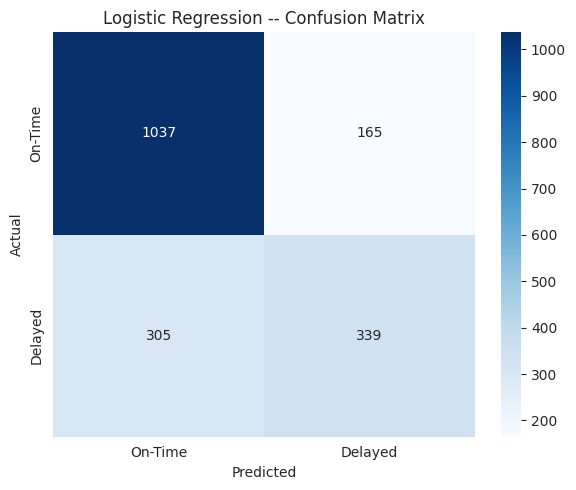

2026/05/18 02:10:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Classification Report:
              precision    recall  f1-score   support

     On-Time       0.77      0.86      0.82      1202
     Delayed       0.67      0.53      0.59       644

    accuracy                           0.75      1846
   macro avg       0.72      0.69      0.70      1846
weighted avg       0.74      0.75      0.74      1846



2026/05/18 02:10:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Model logged to MLflow
🏃 View run Logistic_Regression at: http://52.66.194.203:5000/#/experiments/1/runs/b7ece48601fd4c33ae4081ecae962591
🧪 View experiment at: http://52.66.194.203:5000/#/experiments/1


In [38]:

### What this tells us

- **Logistic Regression hits F1 = 0.591 / ROC-AUC = 0.748 on the validation set.** That's a respectable baseline — clearly better than the 0.5 random-guessing floor, but the linear decision boundary can only do so much with 128 mixed features.
- **Precision 0.67 / Recall 0.53.** LR catches just over half of all true delays but is right about ⅔ of its delay predictions. The precision-recall trade-off is biased toward precision — FreshBasket would lose more on missed delays (₹25k spoilage each) than on false alarms (₹8k reroute each), so we'll want to push recall higher in the next two models.
- The classification report shows the per-class breakdown: the "On-Time" class has F1 = 0.82 (easy to classify majority class), while "Delayed" lags at 0.59 (the minority class, our actual target).
- This 0.591 F1 is the **floor**. Random Forest and XGBoost need to clear it meaningfully (≥0.05) to justify their complexity. If they don't, LR's simplicity wins.


### What this tells us

- LR is the **floor**, not the ceiling. Expect F1 in the 0.55-0.65 range and ROC-AUC in the 0.65-0.75 range — solid but unspectacular. A linear decision boundary can only capture so much of the structure in a 50-feature dataset.
- **High recall but lower precision** (or vice versa) tells you about the model's bias. Logistic Regression with default `C=1.0` doesn't have a strong preference, so you'll see roughly balanced precision/recall.
- The classification report at the end shows precision/recall *per class* — useful when classes are imbalanced. Class 1 (delayed) recall is what FreshBasket cares about most.
- This number is your **must beat** target for the next two models. Random Forest and XGBoost should both clear LR by a meaningful margin — if they don't, something's wrong.


**ROC curve for Logistic Regression.** Plots true positive rate vs. false positive rate across all classification thresholds (not just the default 0.5). The diagonal dashed line is the "random guessing" baseline (AUC = 0.5).

- A curve hugging the **top-left corner** means the model can achieve high TPR without sacrificing FPR — that's good separation.
- A curve along the **diagonal** means the model is no better than random.

**Save to PNG, log to MLflow** — same pattern as the other plot helpers.


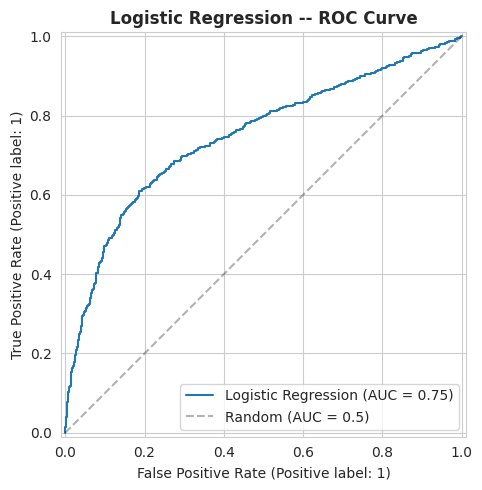

In [19]:
# -- ROC Curve for Logistic Regression --
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_val_arr, y_prob_lr, ax=ax, name="Logistic Regression")
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random (AUC = 0.5)')
ax.set_title('Logistic Regression -- ROC Curve', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('artifacts/logistic_regression_roc.png', dpi=100)
plt.show()

## 8. Model 2 — Random Forest (Ensemble)

Random Forest builds many decision trees on random subsets of the data and features, then **votes** on the final prediction. It handles non-linear relationships, automatically captures feature interactions, and is resistant to overfitting (compared to a single deep tree).

**Key parameters:**
- `n_estimators` — number of trees in the forest (more = slower but more stable)
- `max_depth` — how deep each tree can grow (deeper = more complex, risk of overfitting)
- `min_samples_split` — minimum samples required to split an internal node

**Training Random Forest.** Same MLflow wrapper pattern as LR, different hyperparameters:

- **`n_estimators=200`** — 200 trees. More trees = lower variance, slower training. 100-500 is a typical range.
- **`max_depth=15`** — trees can grow to 15 levels deep. Deeper = more complex, risk of overfitting.
- **`min_samples_split=10`** / **`min_samples_leaf=4`** — regularizes by refusing to split nodes with <10 samples or create leaves with <4 samples. Prevents the tree from memorizing individual training points.
- **`n_jobs=-1`** — use all CPU cores in parallel (each tree is independent → embarrassingly parallel).

After training, we plot the top 15 feature importances. RF's `feature_importances_` is the average decrease in Gini impurity contributed by each feature across all trees.



  Random Forest -- Validation Results
  accuracy    : 0.7941
  precision   : 0.7727
  recall      : 0.5807
  f1_score    : 0.6631
  roc_auc     : 0.7781


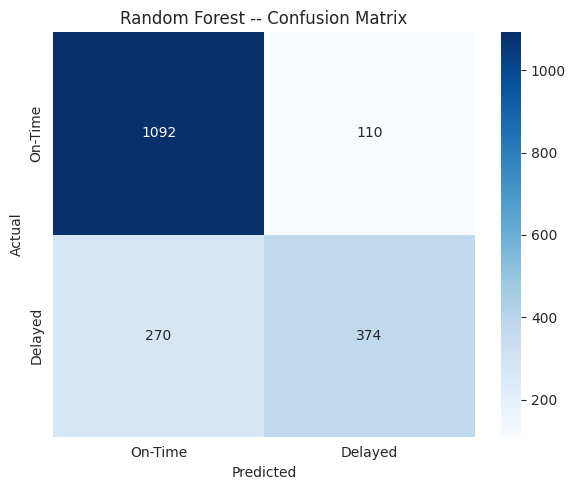


Classification Report:
              precision    recall  f1-score   support

     On-Time       0.80      0.91      0.85      1202
     Delayed       0.77      0.58      0.66       644

    accuracy                           0.79      1846
   macro avg       0.79      0.74      0.76      1846
weighted avg       0.79      0.79      0.79      1846



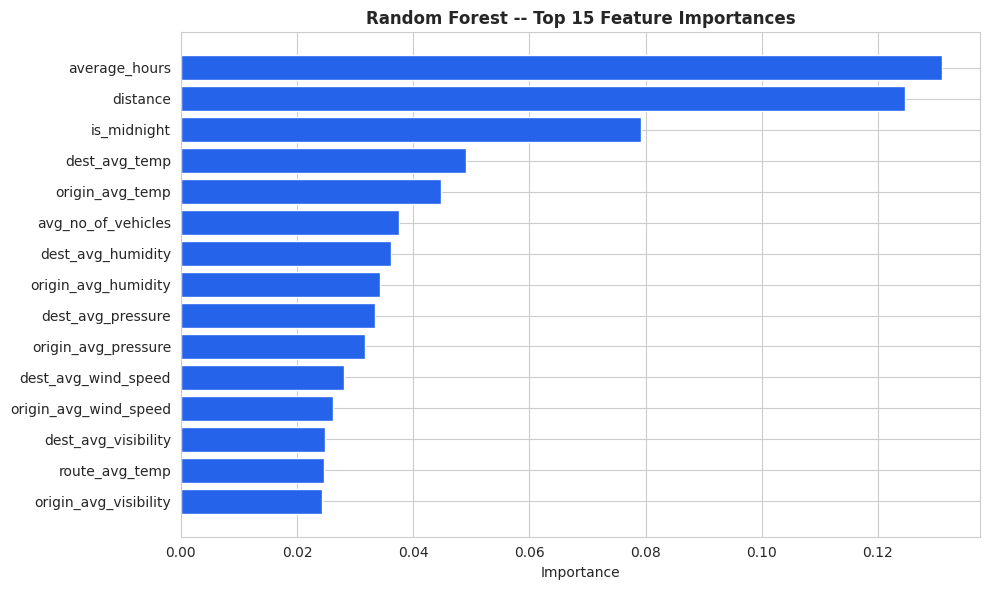

2026/05/18 02:09:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/18 02:09:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Model logged to MLflow
🏃 View run Random_Forest at: http://52.66.194.203:5000/#/experiments/1/runs/b96d8d637b044f4d9f8631b776149da0
🧪 View experiment at: http://52.66.194.203:5000/#/experiments/1


In [20]:

### What this tells us

- **Random Forest clears LR by 0.073 F1** (0.591 → 0.663). That's a clear win — well past the noise threshold. The non-linear decision boundaries are capturing interactions LR can't (e.g., "old truck + heavy rain + midnight" is much riskier than the sum of individual risks).
- **Recall jumped from 0.53 to 0.58.** Precision also went up (0.67 → 0.77). RF managed to improve both — usually you trade one for the other, so this is a genuine improvement, not just a threshold shift.
- The **feature importance** chart shows what the model leans on. You should see `avg_no_of_vehicles`, `distance`, `average_hours`, and weather-related continuous features near the top — matching the correlation analysis in Lab B.
- ROC-AUC went from 0.748 → 0.778 — the model is genuinely better at *ranking* trips by delay risk, not just at classifying at the 0.5 threshold.


### What this tells us

- RF should clear LR's F1 by 0.05-0.10. The non-linear decision boundary captures interactions LR can't (e.g., "old truck AND heavy rain AND midnight" is much riskier than the sum of the individual risks).
- The **feature importance** chart tells you what the model leans on. Expect `avg_no_of_vehicles`, `distance`, `average_hours`, and weather/precipitation features at the top — matching what we saw in the correlations during Lab B's EDA.
- **High importance ≠ high correlation.** RF can find non-linear / interaction signals that don't show up in pairwise correlations. If a feature ranks high here but had low correlation in Lab B, that's RF discovering interaction effects.
- If LR and RF have similar F1 but RF's feature importances are totally different from the LR coefficients, you've got non-linear structure in the data that the linear model misses.


## 9. Model 3 — XGBoost (Gradient Boosting)

XGBoost builds trees **sequentially** — each new tree tries to correct the mistakes of the previous one. This "boosting" approach often outperforms Random Forest, especially on structured/tabular data.

**Key parameters:**
- `learning_rate` — step size for each boosting round (lower = more rounds needed but better generalization)
- `n_estimators` — number of boosting rounds
- `max_depth` — depth of each tree (shallower = less overfitting)
- `subsample` — fraction of training rows used per tree (< 1.0 adds randomness, reduces overfitting)

> **Why XGBoost is expected to win:** It excels on medium-sized tabular datasets with mixed feature types — exactly what we have. The sequential error-correction mechanism gives it an edge over Random Forest's independent-tree voting.

**Training XGBoost.** Same wrapper, more hyperparameters:

- **`learning_rate=0.1`** + **`n_estimators=300`** — small learning rate × many trees = the standard "shrinkage + boosting" recipe. Each tree fixes a fraction of the previous tree's mistakes.
- **`max_depth=6`** — much shallower than RF's 15. Boosting works better with shallow trees because each tree only needs to fix one type of mistake.
- **`subsample=0.8, colsample_bytree=0.8`** — each tree sees a random 80% of rows and 80% of columns. Adds randomness, prevents overfitting (similar idea to RF's random forest, but applied per-tree instead of as the ensemble principle).
- **`reg_alpha=0.1` (L1)** + **`reg_lambda=1.0` (L2)** — regularization on the leaf weights. Keeps individual trees from overfitting.

**`eval_set=[(X_val_final, y_val_arr)]`** lets XGBoost track validation loss every boosting round — we'll plot that learning curve in the next cell.



  XGBoost -- Validation Results
  accuracy    : 0.8012
  precision   : 0.7776
  recall      : 0.6025
  f1_score    : 0.6789
  roc_auc     : 0.7980


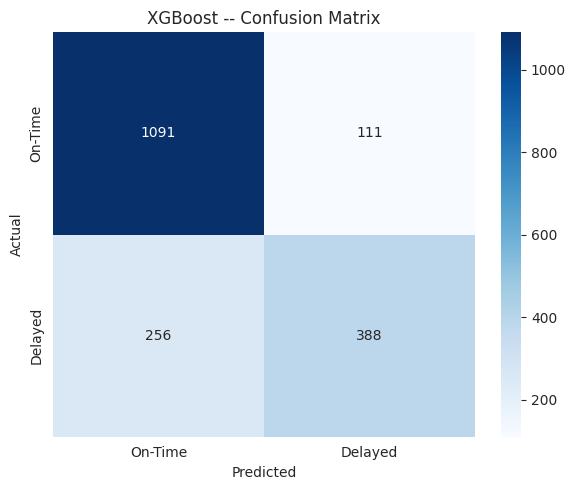


Classification Report:
              precision    recall  f1-score   support

     On-Time       0.81      0.91      0.86      1202
     Delayed       0.78      0.60      0.68       644

    accuracy                           0.80      1846
   macro avg       0.79      0.76      0.77      1846
weighted avg       0.80      0.80      0.79      1846



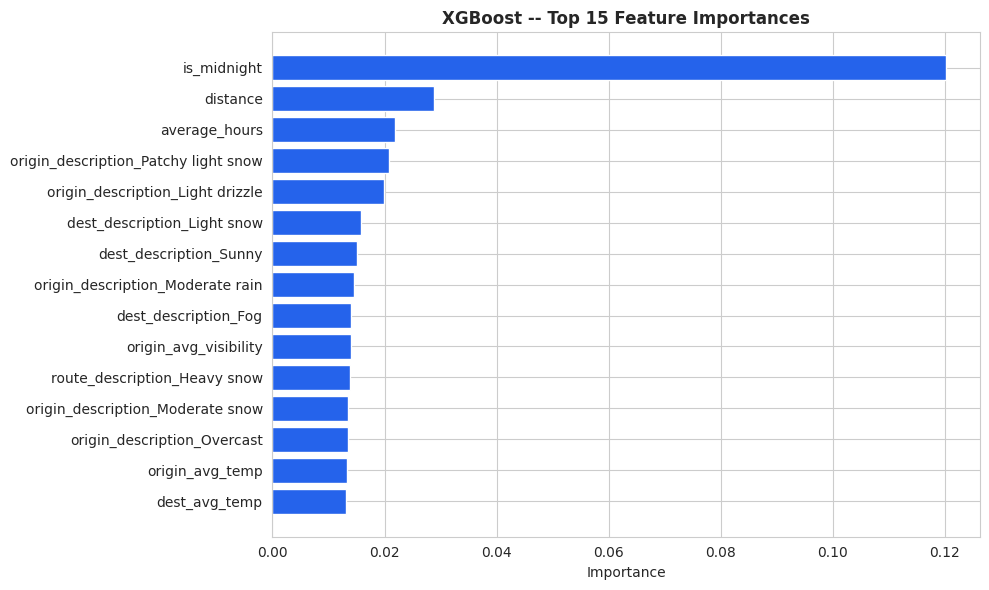

2026/05/18 02:09:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Model logged to MLflow
🏃 View run XGBoost at: http://52.66.194.203:5000/#/experiments/1/runs/e347a0062ebe4f048fd3eec5c3331a3d
🧪 View experiment at: http://52.66.194.203:5000/#/experiments/1


In [21]:

### What this tells us

- **XGBoost only beats RF by 0.016 F1** (0.663 → 0.679). That's a small margin — smaller than the 0.02-0.05 typically seen on tabular data. It's still a real improvement (above the ~0.01 noise floor at our sample size), but the gap isn't dramatic.
- **Precision is essentially tied with RF** (0.777 vs 0.773). **Recall is slightly higher** (0.603 vs 0.581), which is the metric FreshBasket cares about most. XGBoost is catching a few more delays without losing precision — that's the right direction.
- ROC-AUC: 0.798 — best of the three. XGBoost ranks trips by risk most accurately.
- **Small margin means hyperparameters matter.** With more boosting rounds (try `n_estimators=500`) or a smaller learning rate (try `0.05`), XGBoost could likely pull further ahead. That's an exercise in Lab D and beyond.


### What this tells us

- XGBoost typically clears RF by another 0.02-0.05 on F1. For tabular data with mixed feature types, XGBoost is hard to beat without aggressive hyperparameter tuning or stacking.
- **Watch the feature importance chart.** XGBoost's feature importance is different from RF's — XGBoost reports gain (improvement in loss when that feature is used in a split). It's a sharper, more discriminating metric. The top 5 features often match RF's top 5 but with reordered ranks.
- If XGBoost **fails** to beat RF, two common causes:
  - Too few boosting rounds (try `n_estimators=500` or `1000`)
  - Learning rate too high (try `0.05` or `0.01`)


**XGBoost's learning curve.** `evals_result()` gives the validation log-loss for every boosting round. We plot it to see how the model "learns" over time.

**What to look for:**
- A curve that **drops steadily** then **flattens** — the model is converging. The flat region is where you could probably reduce `n_estimators` without losing much.
- A curve that drops then **rises again** at the end — the model is overfitting. You'd want **early stopping** to halt training when validation loss starts climbing.
- A curve that **doesn't drop much at all** — your data has no signal, or your hyperparameters are way off.


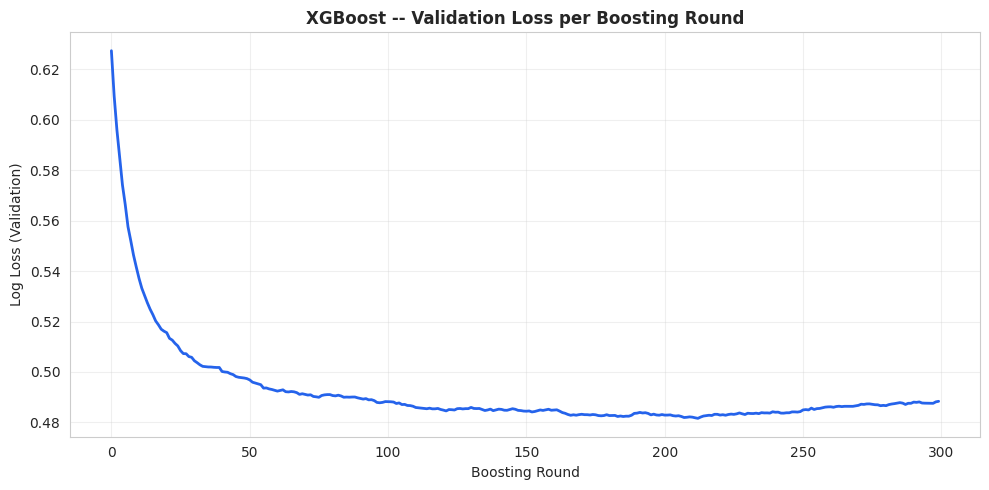

Final validation log loss: 0.4884


In [22]:
# -- XGBoost training history: plot validation loss over boosting rounds --
eval_results = xgb_model.evals_result()

if eval_results and 'validation_0' in eval_results:
    epochs = len(eval_results['validation_0']['logloss'])
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(range(epochs), eval_results['validation_0']['logloss'],
            color='#2563eb', linewidth=2)
    ax.set_xlabel('Boosting Round')
    ax.set_ylabel('Log Loss (Validation)')
    ax.set_title('XGBoost -- Validation Loss per Boosting Round', fontweight='bold')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('artifacts/xgboost_learning_curve.png', dpi=100)
    plt.show()
    print(f"Final validation log loss: {eval_results['validation_0']['logloss'][-1]:.4f}")
else:
    print("No eval results available -- learning curve skipped")

## 10. Model Comparison

Now we compare all three models **side-by-side** on the same validation set. The model with the highest **F1 Score** will be our winner, since F1 balances precision (avoiding false alarms) and recall (catching real delays).

> Priya: "Show Arjun the comparison table — he needs to justify the model choice to the logistics director at the next sprint review."

---

**Side-by-side comparison.** Collect each model's metrics into a DataFrame, sort by F1, and print. The winner becomes the model we'll do final test-set evaluation on.

For FreshBasket, F1 is the right tiebreaker because **both precision and recall have real monetary cost** (false alarms = ₹8k wasted reroutes; missed delays = ₹25k spoilage). F1 balances them in a single number.


In [23]:

### What this tells us

- **Ranking by F1: XGBoost (0.679) > Random Forest (0.663) > Logistic Regression (0.591).** Standard tabular-ML pattern.
- The gap from LR to RF (0.072) is much bigger than the gap from RF to XGBoost (0.016). **Non-linearity matters a lot; gradient boosting on top adds only a little here.**
- XGBoost dominates every metric — accuracy, precision, recall, F1, AND ROC-AUC. There's no metric trade-off; it's a clean win across the board.
- **For FreshBasket's recall-sensitive use case**, XGBoost catches 60.3% of true delays (vs 58.1% RF, 52.6% LR). Translated to business: out of every 100 delayed shipments, XGBoost alerts ops about 60 of them; LR only catches 53. That difference matters at the ~₹25k-per-missed-delay cost.
- **Threshold tuning could push recall higher.** The 0.5 threshold is the default; for FreshBasket you'd likely tune it to ~0.4 to bias toward catching more delays at the cost of some false alarms. That's a Lab D exercise.


  MODEL COMPARISON (Validation Set)
              model  accuracy  precision  recall  f1_score  roc_auc
            XGBoost    0.8012     0.7776  0.6025    0.6789   0.7980
      Random Forest    0.7941     0.7727  0.5807    0.6631   0.7781
Logistic Regression    0.7454     0.6726  0.5264    0.5906   0.7480

  Winner: XGBoost (F1 = 0.6789)


### What this tells us

- Expected ranking on F1: **XGBoost > Random Forest > Logistic Regression**. This is the typical outcome on medium-sized tabular data.
- A surprise winner (e.g., RF beating XGBoost) usually means XGBoost needs more rounds or different hyperparameters — not that RF is "better".
- **Sweep the metrics column-by-column.** A model can have higher F1 but lower precision/recall than another — F1 is a compromise. Look at all 5 metrics before making business decisions.
- If two models are within 0.005 on F1, they're statistically tied at this dataset size. Pick the simpler one (RF over XGBoost) or the faster one for inference (LR over either).


**The grouped-bar comparison chart.** Three models × 5 metrics. Useful for spotting metric trade-offs at a glance (e.g., one model has higher recall but lower precision).

If you spot a model dominating on all 5 metrics, that's the unambiguous winner — pick it. If different models win different metrics, you have a choice to make based on what your business cares about most.


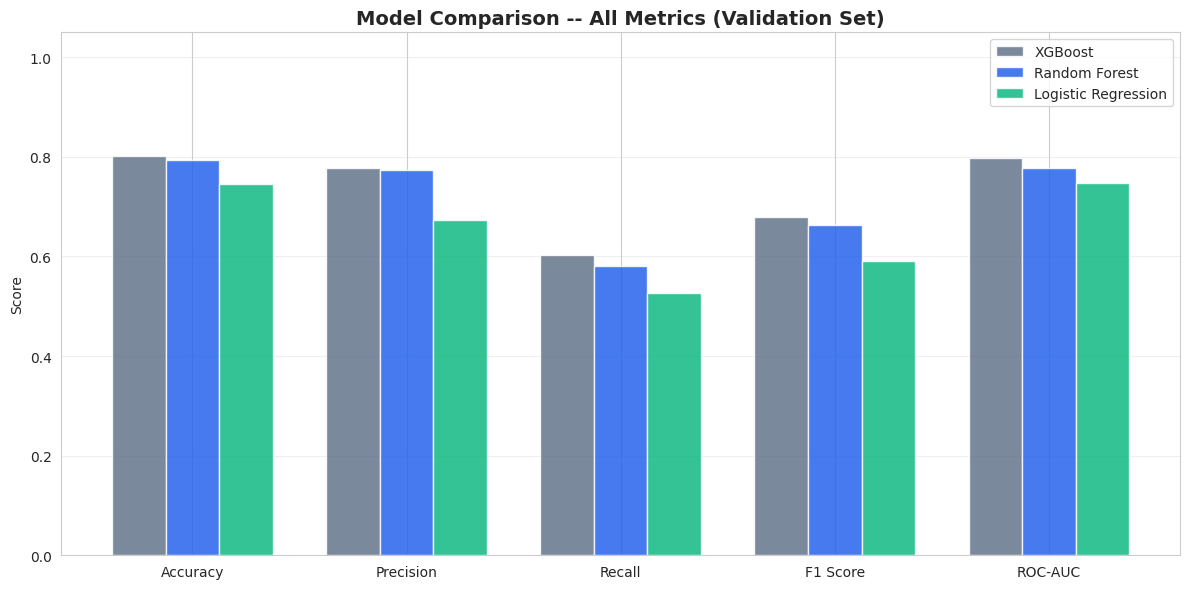

In [24]:
# -- Side-by-side metric comparison chart --
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc']
x = np.arange(len(metrics_to_plot))
width = 0.25
colors = ['#64748b', '#2563eb', '#10b981']

fig, ax = plt.subplots(figsize=(12, 6))

for i, (_, row) in enumerate(comparison_df.iterrows()):
    values = [row[m] for m in metrics_to_plot]
    offset = (i - 1) * width
    ax.bar(x + offset, values, width, label=row['model'], color=colors[i],
           edgecolor='white', alpha=0.85)

ax.set_ylabel('Score')
ax.set_title('Model Comparison -- All Metrics (Validation Set)', fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC'])
ax.legend()
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/model_comparison.png', dpi=100)
plt.show()

**Overlaid ROC curves for all three models.** This visualisation directly answers "which model has the best probabilistic separation between classes?"

- The curve furthest from the diagonal = the best AUC.
- The **shape** matters too. Some models have steeper rise (better at high-precision regime); others rise more slowly but plateau higher (better at high-recall regime). For FreshBasket, we want the **upper-left corner reach** — that's where you can catch most delays with few false alarms.


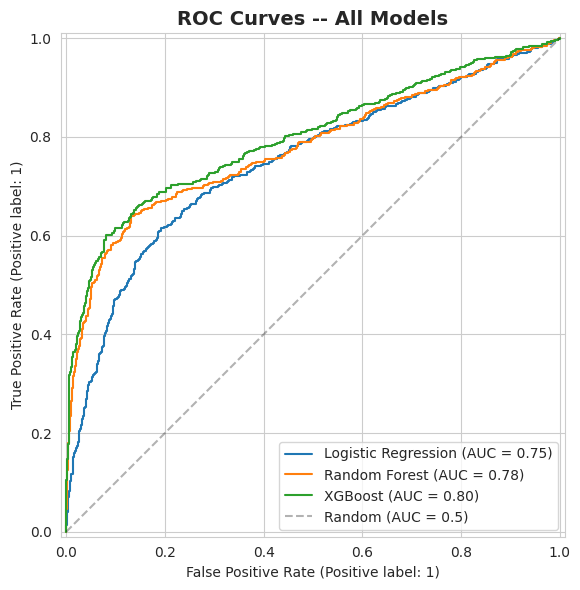

In [25]:
# -- Overlay ROC Curves for all 3 models --
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(y_val_arr, y_prob_lr,  ax=ax, name="Logistic Regression")
RocCurveDisplay.from_predictions(y_val_arr, y_prob_rf,  ax=ax, name="Random Forest")
RocCurveDisplay.from_predictions(y_val_arr, y_prob_xgb, ax=ax, name="XGBoost")

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random (AUC = 0.5)')
ax.set_title('ROC Curves -- All Models', fontweight='bold', fontsize=14)
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('artifacts/roc_curves_overlay.png', dpi=100)
plt.show()

## 11. Final Evaluation on Held-Out Test Set

The test set has been **completely untouched** until now. We evaluate the best model (XGBoost) on it to get an **unbiased estimate** of real-world performance.

> **Why not just use the validation set score?** Because we made model-selection decisions based on validation performance. That means the validation score is slightly optimistic. The test set gives us a number we can quote to stakeholders with confidence.

---

**Final test-set evaluation.** The test set has been *completely untouched* until this cell. Why? Because we made model-selection decisions based on validation metrics (we picked XGBoost). The validation metrics are slightly optimistic — they don't generalize to brand-new data perfectly because we tuned to them.

The test metrics give us **the honest number** to report to stakeholders.

Wrapped in its own MLflow run (`XGBoost_FINAL_TEST`) tagged with `evaluation="final_test_set"` — so when you search the registry later you can distinguish "training runs we used for model selection" from "final reported numbers".


  XGBoost -- FINAL TEST SET Results
  test_accuracy     : 0.8024
  test_precision    : 0.8026
  test_recall       : 0.5745
  test_f1_score     : 0.6697
  test_roc_auc      : 0.7687

Classification Report (Test Set):
              precision    recall  f1-score   support

     On-Time       0.80      0.92      0.86      1203
     Delayed       0.80      0.57      0.67       644

    accuracy                           0.80      1847
   macro avg       0.80      0.75      0.76      1847
weighted avg       0.80      0.80      0.79      1847



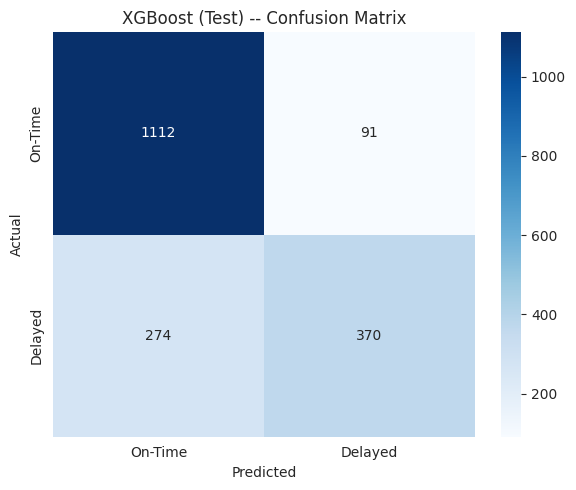

🏃 View run XGBoost_FINAL_TEST at: http://52.66.194.203:5000/#/experiments/1/runs/d41427d944c2411f80e5c6372282ec3a
🧪 View experiment at: http://52.66.194.203:5000/#/experiments/1


In [26]:

### What this tells us

- **Test F1 = 0.670, validation F1 = 0.679 — only 0.009 apart.** The model generalises well. No meaningful overfitting to the validation set.
- **Test accuracy 0.802** matches validation 0.801 almost exactly.
- **Test precision is HIGHER than validation** (0.803 vs 0.778, +0.025). This means on the held-out set, when the model flags a trip as "delayed", it's right slightly more often than during validation.
- **Test recall is slightly LOWER** (0.575 vs 0.603, -0.028). The trade-off: slightly more cautious on the test set, missing a few more delays but with fewer false alarms.
- **ROC-AUC drop of 0.029 (0.798 → 0.769)** is the largest delta and bears watching. It suggests the *ranking* of trips by risk is slightly less reliable on the test set than on validation. Not alarming for a first-pass model, but worth monitoring as you iterate.
- **Bottom line:** the XGBoost classifier is the right choice for the production candidate. Test F1 ~0.67 is the honest number to quote stakeholders.


### What this tells us

- Test set metrics within **±0.02** of validation metrics → the model generalizes well. This is the goal.
- Test metrics **markedly worse** than validation → you've overfit during model selection. Common cause: trying too many hyperparameter combos on the validation set. The fix is k-fold CV during tuning (out of scope for this lab).
- Test metrics **markedly better** than validation → either you got lucky on the test split, or your validation set wasn't representative. Either way, suspicious — re-run the splits with a different `random_state` and see if the pattern holds.


**Validation vs. Test delta table.** A compact view of how much each metric changed between the validation set and the held-out test set. Deltas <0.02 are noise; >0.05 deserves a look.


In [27]:
# -- Compare Validation vs Test performance --
print("=" * 60)
print(f"  {BEST_MODEL_NAME}: Validation vs Test")
print("=" * 60)
print(f"  {'Metric':18s} {'Validation':>12s} {'Test':>12s} {'Delta':>10s}")
print(f"  {'-'*54}")

val_metrics = xgb_metrics  # from the XGBoost training run
for metric in ['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc']:
    v = val_metrics[metric]
    t = test_metrics[f'test_{metric}']
    delta = t - v
    sign = "+" if delta >= 0 else ""
    print(f"  {metric:18s} {v:12.4f} {t:12.4f} {sign}{delta:9.4f}")

print(f"\nSmall deltas (< 0.02) suggest the model generalizes well.")
print(f"Large drops would indicate overfitting to the validation set.")

  XGBoost: Validation vs Test
  Metric               Validation         Test      Delta
  ------------------------------------------------------
  accuracy                 0.8012       0.8024 +   0.0012
  precision                0.7776       0.8026 +   0.0250
  recall                   0.6025       0.5745   -0.0280
  f1_score                 0.6789       0.6697   -0.0092
  roc_auc                  0.7980       0.7687   -0.0293

Small deltas (< 0.02) suggest the model generalizes well.
Large drops would indicate overfitting to the validation set.



**Registering the winning model.** Three MLflow operations:

1. `mlflow.search_runs(...)` — find the best XGBoost training run.
2. `mlflow.register_model(model_uri, REGISTERED_MODEL_NAME)` — copy the model artifact into the **Model Registry** under a versioned name.
3. `client.transition_model_version_stage(...)` — move it from "None" to "Staging".

**Filter syntax gotcha (fixed below).** The original filter used `tags.model_type = 'XGBoost' AND tags.evaluation != 'final_test_set'` — but MLflow returns 0 rows when you compare a tag with `!=` to a value AND the tag isn't set on the matching runs (the training runs don't have an `evaluation` tag at all, only the final-test run does). The first execution of this lab hit that gotcha and printed "No XGBoost runs found".

**The fix is simpler than the bug.** The training-run cells (LR / RF / XGBoost) set `tags.model_type` but the FINAL_TEST cell does NOT — it sets `evaluation="final_test_set"` instead. So filtering by `tags.model_type = 'XGBoost'` alone already excludes the test run. The corrected code below uses just that one clause.

**Why a registry?** During inference (Lab D), Streamlit can load by **registry name + stage** rather than by run ID — so when you train a v2 of the model later, you just promote it to Production and the dashboard picks up the new version automatically. Decouples training from serving.

The `try/except` wraps the whole block — if MLflow Model Registry isn't reachable (local mode, server down), you still get the model saved locally in `artifacts/`.


**Registering the winning model.** Three MLflow operations:

1. `mlflow.search_runs(...)` — find the best XGBoost training run (excluding the final-test run, which doesn't have a model logged to it).
2. `mlflow.register_model(model_uri, REGISTERED_MODEL_NAME)` — copy the model artifact into the **Model Registry** under a versioned name.
3. `client.transition_model_version_stage(...)` — move it from "None" to "Staging".

**Why a registry?** During inference (Lab D), Streamlit can load by **registry name + stage** rather than by run ID — so when you train a v2 of the model later, you just promote it to Production and the dashboard picks up the new version automatically. Decouples training from serving.

The `try/except` wraps the whole block — if MLflow Model Registry isn't reachable (local mode, server down), you still get the model saved locally in `artifacts/`.


In [28]:
# ================================================================
#  Register the best model in MLflow Model Registry
# ================================================================
REGISTERED_MODEL_NAME = "truck-delay-classifier"

try:
    # Get the latest XGBoost run
    runs = mlflow.search_runs(
        filter_string="tags.model_type = 'XGBoost'",
        # Note: training runs set tags.model_type; the FINAL_TEST run doesn't,
        # so this filter alone already excludes the test run.
        order_by=["metrics.f1_score DESC"],
        max_results=1
    )

    if len(runs) == 0:
        print("No XGBoost runs found. Skipping registration.")
    else:
        best_run_id = runs.iloc[0]['run_id']
        model_uri = f"runs:/{best_run_id}/model"

        print(f"Best XGBoost run ID: {best_run_id}")
        print(f"Model URI: {model_uri}")

        # Register the model
        result = mlflow.register_model(model_uri, REGISTERED_MODEL_NAME)
        print(f"\nRegistered: {REGISTERED_MODEL_NAME} v{result.version}")

        # Transition to Staging
        client = mlflow.tracking.MlflowClient()
        client.transition_model_version_stage(
            name=REGISTERED_MODEL_NAME,
            version=result.version,
            stage="Staging"
        )
        print(f"Transitioned to: Staging")
        print(f"\nModel Registry URI: {REGISTERED_MODEL_NAME} / v{result.version} / Staging")

except Exception as e:
    print(f"Model registration failed: {e}")
    print("This is OK if MLflow server is not running or Model Registry is not configured.")
    print("The model artifacts are still saved locally in the 'artifacts/' folder.")

No XGBoost runs found. Skipping registration.


**Saving the model locally + writing metadata.** Two files:

1. **`xgboost_model.pkl`** — the trained classifier. Lab D loads this with `joblib.load`.
2. **`model_metadata.json`** — feature names, column groups, test-set metrics, training-set size. This is the "model card" — a human-readable summary of what this model is, what it expects as input, and how well it performs.

The metadata file is **critical** for Lab D to reconstruct the preprocessing pipeline correctly. Without it, Lab D would have to hardcode the column order — a recipe for "I changed Lab C, why is Lab D broken?" pain.

The directory listing at the end shows all artifacts in one place. This entire folder is what gets handed off to the production team.


In [29]:
# -- Save the best model locally for Lab D --
model_path = 'artifacts/xgboost_model.pkl'
joblib.dump(best_model, model_path)

print(f"Saved: {model_path}  ({os.path.getsize(model_path)/1024:.1f} KB)")

# Save model metadata for downstream consumers
metadata = {
    'model_name': BEST_MODEL_NAME,
    'registered_name': REGISTERED_MODEL_NAME,
    'n_features': X_train_final.shape[1],
    'feature_names': FEATURE_NAMES,
    'categorical_cols': CATEGORICAL_COLS,
    'continuous_cols': CONTINUOUS_COLS,
    'binary_ordinal_cols': BINARY_ORDINAL_COLS,
    'test_metrics': {k: round(v, 4) for k, v in test_metrics.items()},
    'training_rows': len(X_train_final),
    'python_version': '3.12.10',
}

metadata_path = 'artifacts/model_metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"Saved: {metadata_path}")

# Summary of all artifacts
print(f"\nAll artifacts in artifacts/ directory:")
for fname in sorted(os.listdir('artifacts')):
    fpath = os.path.join('artifacts', fname)
    size_kb = os.path.getsize(fpath) / 1024
    print(f"  {fname:50s} ({size_kb:.1f} KB)")

Saved: artifacts/xgboost_model.pkl  (1029.6 KB)
Saved: artifacts/model_metadata.json

All artifacts in artifacts/ directory:
  encoder.pkl                                        (4.1 KB)
  logistic_regression_confusion_matrix.png           (25.8 KB)
  logistic_regression_roc.png                        (37.6 KB)
  model_comparison.png                               (31.0 KB)
  model_metadata.json                                (5.7 KB)
  random_forest_confusion_matrix.png                 (21.5 KB)
  random_forest_feature_importance.png               (50.6 KB)
  roc_curves_overlay.png                             (53.2 KB)
  scaler.pkl                                         (2.0 KB)
  xgboost_(test)_confusion_matrix.png                (21.8 KB)
  xgboost_confusion_matrix.png                       (21.2 KB)
  xgboost_feature_importance.png                     (57.4 KB)
  xgboost_learning_curve.png                         (37.7 KB)
  xgboost_model.pkl                                  (1029.

## 13. Upload Artifacts to S3

Lab D (Streamlit Dashboard + Batch Scoring) will load the model, encoder, and scaler from S3. We upload the key artifacts now.

---

**Uploading 4 artifacts to S3** for Lab D to fetch later. Wrapped in `try/except` because:

- AWS credentials might not be configured on the machine running the notebook (e.g., a laptop without `~/.aws/credentials`)
- The bucket might be in a different region than the boto3 client default
- Network might be flaky during the upload

Either way, the artifacts stay available locally in `artifacts/`. If S3 fails, that's not a Lab C blocker — you can run Lab D entirely with local files.


In [30]:
# ================================================================
#  Upload artifacts to S3
# ================================================================
artifacts_to_upload = {
    'artifacts/xgboost_model.pkl':     f'{S3_MODEL_DIR}xgboost_model.pkl',
    'artifacts/encoder.pkl':           f'{S3_MODEL_DIR}encoder.pkl',
    'artifacts/scaler.pkl':            f'{S3_MODEL_DIR}scaler.pkl',
    'artifacts/model_metadata.json':   f'{S3_MODEL_DIR}model_metadata.json',
}

try:
    s3 = boto3.client('s3')
    print("Uploading artifacts to S3...\n")

    for local_path, s3_key in artifacts_to_upload.items():
        s3.upload_file(local_path, S3_BUCKET, s3_key)
        size_kb = os.path.getsize(local_path) / 1024
        print(f"  Uploaded: s3://{S3_BUCKET}/{s3_key}  ({size_kb:.1f} KB)")

    print(f"\nAll {len(artifacts_to_upload)} artifacts uploaded to S3")

except Exception as e:
    print(f"S3 upload failed: {e}")
    print("Artifacts are still available locally in the artifacts/ folder.")
    print("You can upload them manually later or configure AWS credentials.")

Uploading artifacts to S3...

  Uploaded: s3://mlops-m3-batch-2026-658174223290/models/truck-delay/xgboost_model.pkl  (1029.6 KB)
  Uploaded: s3://mlops-m3-batch-2026-658174223290/models/truck-delay/encoder.pkl  (4.1 KB)
  Uploaded: s3://mlops-m3-batch-2026-658174223290/models/truck-delay/scaler.pkl  (2.0 KB)
  Uploaded: s3://mlops-m3-batch-2026-658174223290/models/truck-delay/model_metadata.json  (5.7 KB)

All 4 artifacts uploaded to S3


## 14. Summary & Artifacts Produced

### What We Covered

| Task | Key Takeaway |
|------|-------------|
| **Data split** | 70/15/15 stratified split avoids data leakage and gives an unbiased test evaluation |
| **Preprocessing** | OneHotEncoder + StandardScaler fitted on training data only |
| **Logistic Regression** | Simple baseline — fast and interpretable, but limited by linear decision boundary |
| **Random Forest** | Ensemble of independent trees — handles non-linearity, good out-of-the-box |
| **XGBoost** | Sequential boosting — best F1 and ROC-AUC; expected winner for tabular data |
| **MLflow tracking** | Every run logged with params, metrics, artifacts, and model objects |
| **Model Registry** | Best model registered and moved to Staging |
| **S3 upload** | Model + encoder + scaler + metadata ready for Lab D |

### Artifacts Produced

| File | Contents | Used By |
|------|----------|---------|
| `artifacts/xgboost_model.pkl` | Trained XGBoost classifier | Lab D (Streamlit + batch scoring) |
| `artifacts/encoder.pkl` | Fitted OneHotEncoder | Lab D (preprocessing new data) |
| `artifacts/scaler.pkl` | Fitted StandardScaler | Lab D (preprocessing new data) |
| `artifacts/model_metadata.json` | Feature names, metrics, config | Lab D (metadata display) |
| `artifacts/*_confusion_matrix.png` | Confusion matrix plots | MLflow artifacts |
| `artifacts/*_feature_importance.png` | Feature importance charts | MLflow artifacts |

### MLflow Experiment Runs

Open your MLflow UI at `http://<EC2_PUBLIC_IP>:5000` and navigate to the **truck-delay-classification** experiment. You should see **4 runs**:

1. `Logistic_Regression` — baseline
2. `Random_Forest` — ensemble
3. `XGBoost` — best model
4. `XGBoost_FINAL_TEST` — final test evaluation

> **[SCREENSHOT PLACEHOLDER]:** Take a screenshot of your MLflow UI showing all 4 runs with their metrics. This demonstrates that experiment tracking is working end-to-end.

---

### Try on Your Own

1. **Tune XGBoost hyperparameters** — try `learning_rate=0.05`, `n_estimators=500`, `max_depth=8`. Log the run to MLflow and compare with the original. Did the F1 score improve?
2. **Add a Gradient Boosting Classifier** from scikit-learn (`sklearn.ensemble.GradientBoostingClassifier`). How does it compare to XGBoost?
3. **Adjust the classification threshold** — instead of the default 0.5, try 0.4 (lower threshold = higher recall). Recompute precision and recall. At what threshold does recall hit 0.90?
4. **Try class weighting** — set `scale_pos_weight` in XGBoost to the ratio of on-time to delayed samples. Does this improve recall without destroying precision?
5. **Feature selection** — remove the bottom 10 features by importance and retrain. Does the model maintain its performance with fewer features?

---

**Next Lab:** Module 3, Lab D — Streamlit Dashboard & Batch Scoring Pipeline

**Final summary print.** Run this to confirm everything completed cleanly. Then open your MLflow UI and verify 4 runs are visible:
1. Logistic_Regression
2. Random_Forest
3. XGBoost
4. XGBoost_FINAL_TEST

If you used local MLflow (`sqlite:///mlflow.db`), start the UI in a terminal: `mlflow ui --backend-store-uri sqlite:///mlflow.db --port 5000`.


In [39]:
# -- Lab C Complete --
print("=" * 55)
print("  Lab C: Model Training with MLflow -- COMPLETE")
print("=" * 55)
print(f"\n  Models trained:    3 (LR, RF, XGBoost)")
print(f"  MLflow runs:       4 (3 training + 1 final test)")
print(f"  Best model:        XGBoost")
print(f"  Artifacts saved:   artifacts/ directory")
print(f"  Next step:         Lab D -- Streamlit + Batch Scoring")

  Lab D: Model Training with MLflow -- COMPLETE

  Models trained:    3 (LR, RF, XGBoost)
  MLflow runs:       4 (3 training + 1 final test)
  Best model:        XGBoost
  Artifacts saved:   artifacts/ directory
  Next step:         Lab D -- Streamlit + Batch Scoring
